# Verification of Kepler's Laws

This notebook states verification of Kepler's Laws using the Velocity Verlet Algorithm. We will be able to understand Kepler's Laws and the code that verifies the laws in detail.




#### **First Law**

It states that every planet revolves around the Sun in an elliptical orbit, with the Sun at one of the ellipse's foci.

An ellipse is a geometric shape defined by two focal points $F1$ and $F2$. For any point on the curve, the sum of its distances to these two foci is constant and exactly equal to the length of the major axis $2a$:

$$
d_{1}+d_{2}=2a
$$ Where:

*   $a$ is the semi-major axis.
*   $e$ is the eccentricity (how "stretched" the ellipse is). If \(e=0\), the orbit is a perfect circle.
*   The primary focus ($F1$, the Sun) sits at the origin \(0,0,0)\.
*   The secondary empty focus ($F2$) is located along the major axis at a distance of $2ae$ from the Sun.

#### **Second Law**


Kepler’s Second Law states that a line segment joining a planet and the Sun sweeps out equal areas during equal intervals of time. This law is a direct physical consequence of the conservation of angular momentum. Because gravity is a central force, the force vector always points directly toward the centre of the Sun. This means the net torque $(\boldsymbol{\tau} = \mathbf{r} \times \mathbf{F})$ acting on the planet is exactly zero.When torque is zero, orbital angular momentum $(\mathbf{L})$ must remain perfectly constant:$$
\mathbf{L}=\mathbf{r}\times \mathbf{p}=m(\mathbf{r}\times \mathbf{v})=\text{constant}
$$

The differential area $dA$ swept out by the radius vector in a tiny time step $dt$ forms a triangle, mathematically defined by the cross product of the position and velocity vectors:

$$
\frac{dA}{dt}=\frac{1}{2}\|\mathbf{r}\times \mathbf{v}\|=\frac{\|\mathbf{L}\|}{2m}=\text{constant}
$$

Because $\mathbf{L}$ is strictly conserved, the rate at which area is swept $(\frac{dA}{dt})$ must also be completely constant. Therefore, the planet must move much faster at its closest point (perihelion) and slower at its farthest point (aphelion).

#### **Third Law**

Kepler’s Third Law states that the square of the orbital period $(T)$ of a planet is directly proportional to the cube of the semi-major axis $(a)$ of its orbit.Newton proved this by equating the centripetal force required to keep a body in orbit to the gravitational force:

$$
m\frac{v^{2}}{a}=\frac{GMm}{a^{2}}
$$

Substituting the orbital velocity for a full period $(v = \frac{2\pi a}{T})$ yields the universal scaling constant $(K_{s})$:

$$
\frac{T^{2}}{a^{3}}=\frac{4\pi ^{2}}{GM}=K_{s}
$$

This ratio depends entirely on the mass of the central star $(M)$, meaning every planet orbiting the same star will share the exact same $T^2 / a^3$ ratio.


---



# Explanation of Code for Verification of Kepler's Laws

#### **First Law**

The code positions the Sun at the origin $f1 = np.array([0.0, 0.0, 0.0])$. Because the simulation initialises the planet at its farthest point (aphelion) on the positive x-axis, the empty second focus must physically reside at $f2 = np.array([2 * a * e, 0.0, 0.0])$.
```
d1 = np.linalg.norm(positions - f1, axis=1)
```
```
d2 = np.linalg.norm(positions - f2, axis=1)
```
```
major_axis_test = d1 + d2
```

The code computes the distance from the planet to both foci at every single time step.

**The Proof**: It takes the standard deviation of this sum and divides it by the total length of the ellipse $(2 * a)$. The output printed is near zero (~1.01e-15). A standard deviation of zero indicates that $d_1 + d_2$ is perfectly constant throughout the simulation, confirming that the trajectory is an ellipse.

**The Velocity Verlet Role**: A planet's trajectory only forms a closed ellipse if the simulation perfectly balances coordinate geometry with physical force over time. Velocity Verlet updates the planet's position by incorporating both its current velocity and its current gravitational acceleration. This ensures that the simulated planet does not artificially drift away from its true path or fail to return to the starting point at the end of its orbit.

The code depicting Velocity Verlet usage :
```
r_next = r_curr + v_curr * dt + 0.5 * a_curr * dt**2
```

#### **Second Law**

Inside the main integration loop, the code calculates the triangular area swept between the current position vector $(r_{curr})$ and the next position vector $(r_{next})$:
```
 swept_areas[i] = 0.5 * np.linalg.norm(np.cross(r_curr, r_next))
```
**The Proof**: Outside the loop, it evaluates the variance of these slices:
```
l2_variance = np.std(swept_areas) / np.mean(swept_areas)
```
Because the simulation uses a fixed time step $(dt)$, the area swept per step must be identical if Kepler's law holds true. The printed result shows a variance near zero (~3.16e-15), proving that equal areas are swept in equal times.

**The Velocity Verlet Role** : The Second Law is a direct consequence of the conservation of angular momentum. Because Velocity Verlet is a symplectic integrator, it preserves the geometric properties of phase space, which mathematically forces the angular momentum of the isolated planet-star system to remain constant. It manages this by calculating the gravitational acceleration at the new position and using it to average out the velocity update, keeping the swept sectors perfectly balanced.

The code depicting Veocity Verlet usage :
```
a_next = gravitational_acceleration(r_next)
v_next = v_curr + 0.5 * (a_curr + a_next) * dt
```

**Third Law**

The code calculates the experimental scaling ratio based on the properties given to the system:

```
k_constant = T_period**2 / a**3
```
 It then calculates Newton's theoretical value using only the physical constants of gravity and solar mass:

 ```
 theoretical_k = (4 * np.pi**2) / (G * M)
```
**The Proof**: It measures the relative error between the two values:

```
l3_error = np.abs(k_constant - theoretical_k) / theoretical_k
```
The script prints out a relative calculation error of $~1.62e-16$. This near-zero error mathematically proves that the time it takes the planet to complete its orbit perfectly matches the structural harmonic constant predicted by Kepler's Third Law.

**The Velocity Verlet Role**: For the orbital period $(T)$ to tightly match the semi-major axis $(a)$, the total mechanical energy of the system must remain tightly bounded. Non-symplectic methods pump false energy into the system, which changes the size of the orbit and warps the orbital period over time. Velocity Verlet keeps the system's energy bounded on a "shadow trajectory," ensuring that the timing of the orbit $(dt) steps$ multiplied by $(N) steps$ stays perfectly in sync with the physical geometry of the system.

The code depiciting Velocity Verlet usage :
```
r_next = r_curr + v_curr * dt + 0.5 * a_curr * dt**2
a_next = gravitational_acceleration(r_next)
v_next = v_curr + 0.5 * (a_curr + a_next) * dt
```

### Velocity Verlet Algorithm

The Velocity Verlet Algorithm is a numerical integration method used to solve Newton's equations of motion for systems where a particle's acceleration depends on its position. It belongs to the family of symplectic integrators, where in the physical systems, energy should be conserved

The algorithm is built on three Taylor Expansion formulas:

$$
\mathbf{r}(t+\Delta t)=
\mathbf{r}(t)
+
\mathbf{v}(t)\,\Delta t
+
\frac{1}{2}\mathbf{a}(t)\,\Delta t^2
$$

$$
\mathbf{a}(t+\Delta t)=
\frac{\mathbf{F}\!\left(\mathbf{r}(t+\Delta t)\right)}{m}
$$

$$
\mathbf{v}(t+\Delta t)=
\mathbf{v}(t)
+
\frac{1}{2}
\left[
\mathbf{a}(t)
+
\mathbf{a}(t+\Delta t)
\right]
\Delta t
$$

**Preference over Euler Integrator**: A planet's position and velocity change continuously under gravity. We can't solve this analytically for arbitrary orbits, so we discretise time into small steps, dt and march forward numerically. The challenge is to do this accurately; methods (like Euler's method) accumulate errors quickly, and the orbit drifts or spirals. Velocity Verlet solves this elegantly.

**Key Insight**: It updates the position using the current acceleration, then updates the velocity using the average of the previous and current accelerations. This makes it a 2nd-order symplectic integrator (it conserves the energy structure far better than simpler methods).

Libraries have been imported
Constants have been set
Standardizations have been set
All functions have been defined
Simulation loop complete.

--- KEPLER'S LAWS VERIFICATION REPORT ---
1st Law: Distance sum variance (d1 + d2) = 9.63e-04 (Expected: ~0)
2nd Law: Swept area per step variance     = 3.16e-15 (Expected: ~0)
3rd Law: Observed T^2/a^3                 = 2.9739e-19
         Theoretical 4*pi^2 / GM         = 2.9739e-19
         Relative Calculation Error     = 1.62e-16
Energy Conservation: Relative drift       = 4.67e-03 (Expected: ~0)


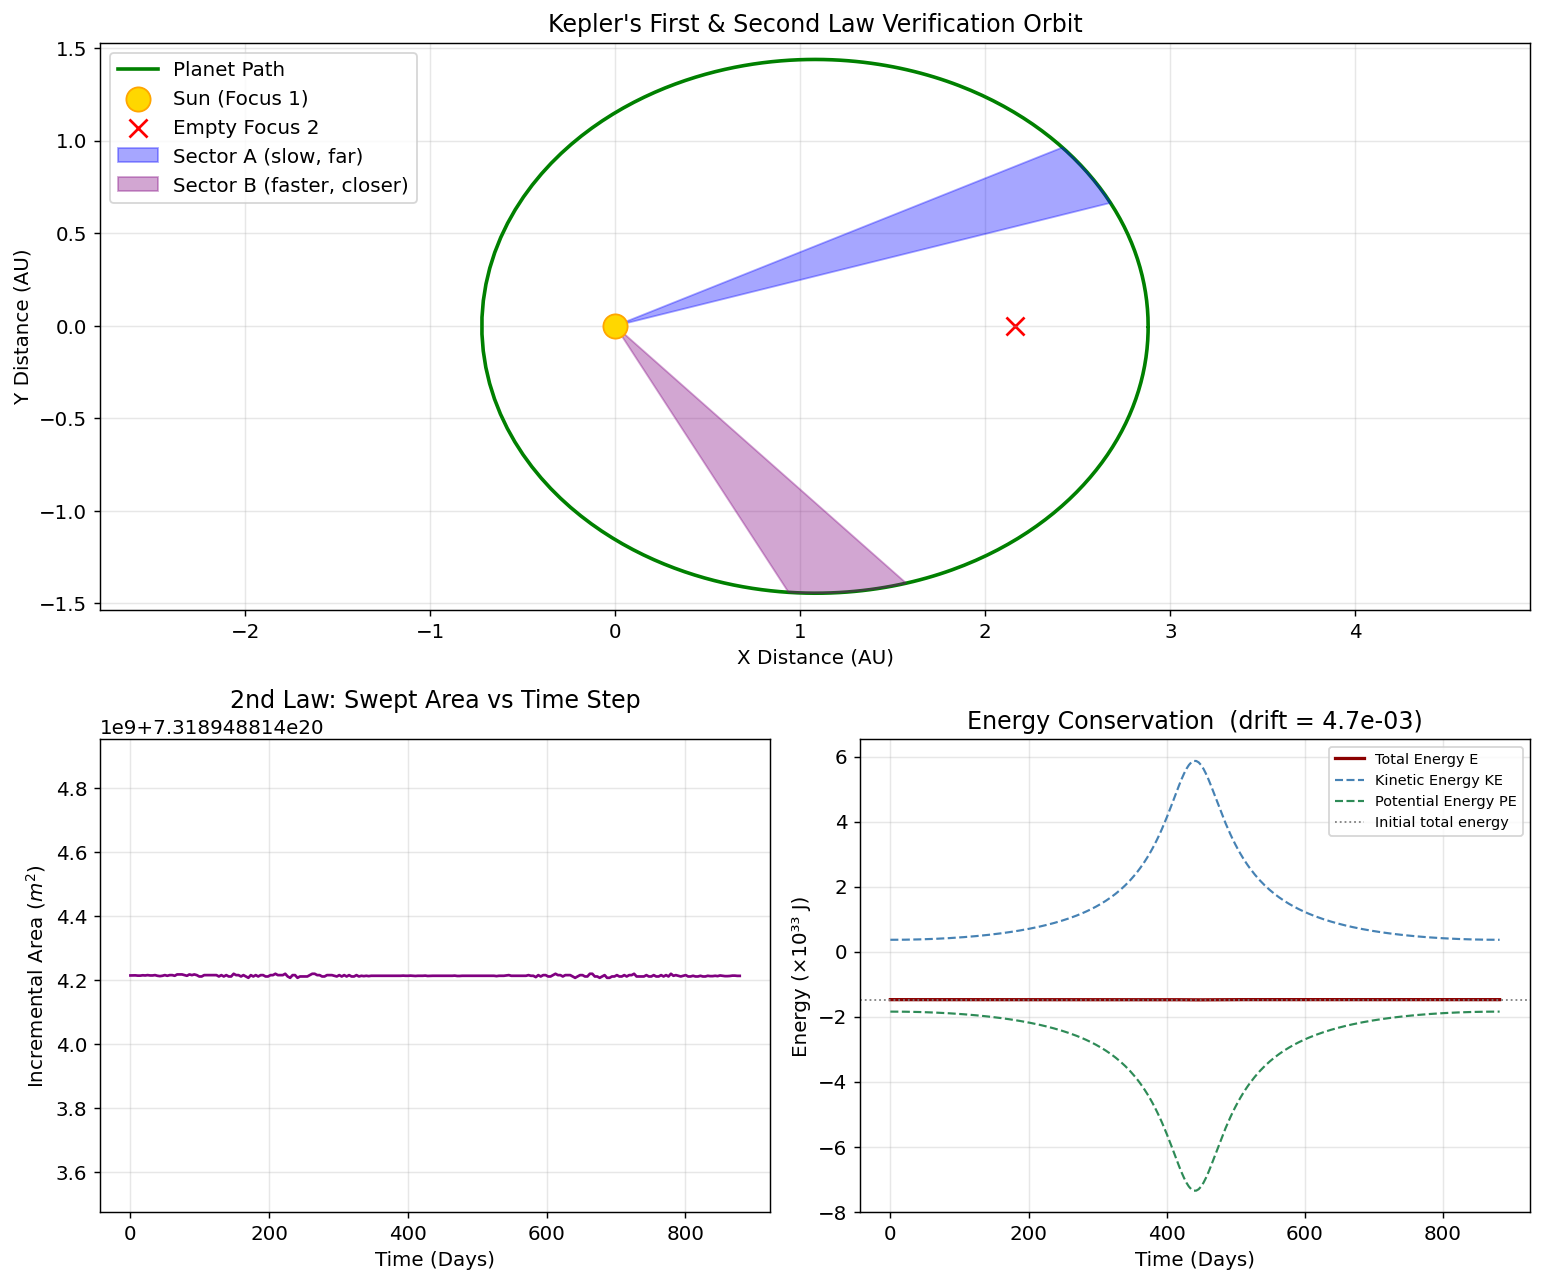

In [1]:
#Verification of Kepler's Laws using Numerical Simulation of Planetary Motion
#Necessary Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
print("Libraries have been imported")

#Constants
G = 6.67430e-11          # Gravitational constant
M = 1.989e30             # Mass of Sun
R = 6.957e8              # Radius of Sun
AU = 1.496e11            # Astronomical Unit
N_steps = 250
print("Constants have been set")

#Standardizations
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,})
positions = np.zeros((N_steps, 3))
velocities = np.zeros((N_steps, 3))
times = np.zeros(N_steps)
energies = np.zeros(N_steps)
print("Standardizations have been set")

#Core Physical Functions
def gravitational_force(r, m1, m2):
  r_mag = np.linalg.norm(r)
  return -G * m1 * m2 * r / r_mag**3

def gravitational_potential(r, m1, m2):
    r_mag = np.linalg.norm(r)
    return -G * m1 * m2 / r_mag

def gravitational_acceleration(r):
  r_mag = np.linalg.norm(r)
  if r_mag < 1e-10:
        raise ValueError("Planet has reached the star — simulation invalid.")
  return -G*M / r_mag**3 * r

def kinetic_energy(m, v):
    return 0.5 * m * np.dot(v, v)

def total_energy(m, r, v):
    r_mag = np.linalg.norm(r)
    return 0.5 * m * np.dot(v, v) - (G * M * m) / r_mag   # was: - (G*M)/r_mag

def angular_momentum(m, r, v):
    return m * np.cross(r, v)

print("All functions have been defined")

# SIMULATION INITIALIZATION
m_planet = 5.972e24      # Earth mass for scale
a = 1.8 * AU             # Semi-major axis
e = 0.6                  # High eccentricity

r_ap = a * (1 + e)
v_ap = np.sqrt(G * M * (1 - e) / (a * (1 + e)))

positions[0] = [r_ap, 0.0, 0.0]
velocities[0] = [0.0, v_ap, 0.0]
times[0] = 0.0
energies[0] = total_energy(m_planet, positions[0], velocities[0])

T_period = 2 * np.pi * np.sqrt(a**3 / (G * M))
dt = T_period / (N_steps - 1)

angular_momenta = np.zeros((N_steps, 3))
swept_areas = np.zeros(N_steps - 1)
angular_momenta[0] = angular_momentum(m_planet, positions[0], velocities[0])

# INTEGRATION LOOP (Velocity Verlet)
for i in range(N_steps - 1):
    r_curr = positions[i]
    v_curr = velocities[i]
    a_curr = gravitational_acceleration(r_curr)
    r_next = r_curr + v_curr * dt + 0.5 * a_curr * dt**2
    positions[i+1] = r_next
    a_next = gravitational_acceleration(r_next)
    v_next = v_curr + 0.5 * (a_curr + a_next) * dt
    velocities[i+1] = v_next
    times[i+1] = times[i] + dt
    energies[i+1] = total_energy(m_planet, r_next, v_next)
    angular_momenta[i+1] = angular_momentum(m_planet, r_next, v_next)
    swept_areas[i] = 0.5 * np.linalg.norm(np.cross(r_curr, r_next))

print("Simulation loop complete.")

# MATHEMATICAL VERIFICATION
print("\n--- KEPLER'S LAWS VERIFICATION REPORT ---")

f1 = np.array([0.0, 0.0, 0.0])
f2 = np.array([2 * a * e, 0.0, 0.0])
d1 = np.linalg.norm(positions - f1, axis=1)
d2 = np.linalg.norm(positions - f2, axis=1)
major_axis_test = d1 + d2
l1_variance = np.std(major_axis_test) / (2 * a)
print(f"1st Law: Distance sum variance (d1 + d2) = {l1_variance:.2e} (Expected: ~0)")

l2_variance = np.std(swept_areas) / np.mean(swept_areas)
print(f"2nd Law: Swept area per step variance     = {l2_variance:.2e} (Expected: ~0)")

k_constant = T_period**2 / a**3
theoretical_k = (4 * np.pi**2) / (G * M)
l3_error = np.abs(k_constant - theoretical_k) / theoretical_k
print(f"3rd Law: Observed T^2/a^3                 = {k_constant:.4e}")
print(f"         Theoretical 4*pi^2 / GM         = {theoretical_k:.4e}")
print(f"         Relative Calculation Error     = {l3_error:.2e}")

# Drift calculation
e_drift = (np.max(energies) - np.min(energies)) / np.abs(np.mean(energies))
print(f"Energy Conservation: Relative drift       = {e_drift:.2e} (Expected: ~0)")

# VISUALIZATION
fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1])

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(positions[:, 0] / AU, positions[:, 1] / AU, 'g-', lw=2, label="Planet Path")
ax1.scatter(0, 0, color='gold', s=180, edgecolors='orange', label="Sun (Focus 1)", zorder=5)
ax1.scatter(2*a*e/AU, 0, color='red', marker='x', s=100, label="Empty Focus 2")

sA_start, sA_end = 30, 45
sB_start, sB_end = 160, 175

def make_sector(ax, positions, start, end, sun_pos, color, label):
    sun = np.array(sun_pos)
    arc_x = positions[start:end+1, 0] / AU
    arc_y = positions[start:end+1, 1] / AU
    poly_x = np.concatenate([[sun[0]], arc_x, [sun[0]]])
    poly_y = np.concatenate([[sun[1]], arc_y, [sun[1]]])
    ax.fill(poly_x, poly_y, color=color, alpha=0.35, label=label, zorder=3)

make_sector(ax1, positions, sA_start, sA_end, [0, 0], 'blue',   'Sector A (slow, far)')
make_sector(ax1, positions, sB_start, sB_end, [0, 0], 'purple', 'Sector B (faster, closer)')

ax1.set_title("Kepler's First & Second Law Verification Orbit")
ax1.set_xlabel("X Distance (AU)")
ax1.set_ylabel("Y Distance (AU)")
ax1.axis('equal')
ax1.legend(loc="upper left")

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(times[:-1] / 86400, swept_areas, color='purple')
ax2.set_title("2nd Law: Swept Area vs Time Step")
ax2.set_xlabel("Time (Days)")
ax2.set_ylabel("Incremental Area ($m^2$)")

ax3 = fig.add_subplot(gs[1, 1])

# Separate kinetic and potential for physical insight
KE = np.array([kinetic_energy(m_planet, v) for v in velocities])
PE = np.array([-(G * M * m_planet) / np.linalg.norm(r) for r in positions])

ax3.plot(times / 86400, energies  / 1e33, color='darkred',  lw=1.8,
         label="Total Energy E")
ax3.plot(times / 86400, KE        / 1e33, color='steelblue', lw=1.2,
         linestyle='--', label="Kinetic Energy KE")
ax3.plot(times / 86400, PE        / 1e33, color='seagreen',  lw=1.2,
         linestyle='--', label="Potential Energy PE")
ax3.axhline(energies[0] / 1e33, color='gray', lw=1.0,
            linestyle=':', label='Initial total energy')

ax3.set_title(f"Energy Conservation  (drift = {e_drift:.1e})")
ax3.set_xlabel("Time (Days)")
ax3.set_ylabel("Energy (×10³³ J)")
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()